In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from circuit_library.mesh_rectangular.cell import rectangular_interferometer
from axiomatic.pic_helpers import plot_circuit

# Example usage
if __name__ == "__main__":
    c = rectangular_interferometer(total_number_unit_cells=10, number_vertical_unit_cells=2)
    plot_circuit(c)



NameError: name 'neighbors' is not defined

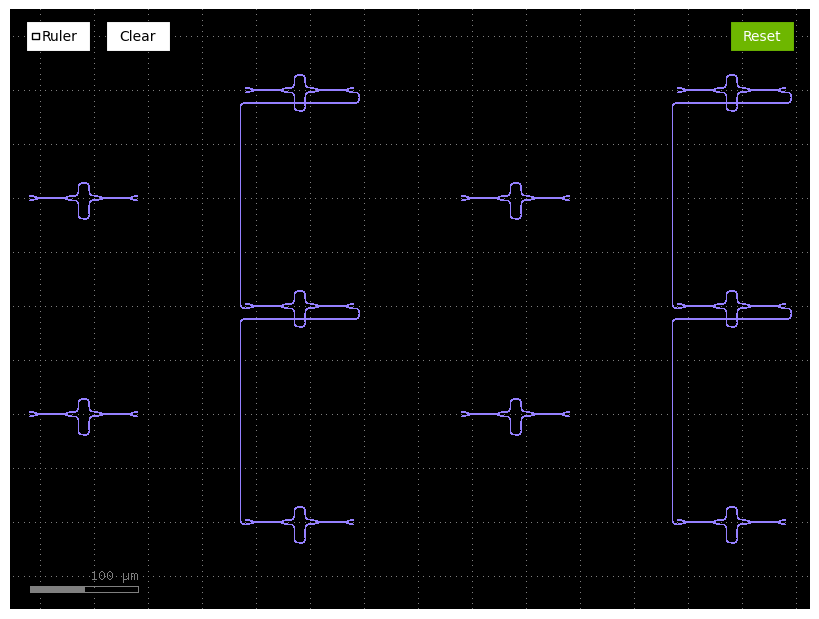

In [1]:
import gdsfactory as gf
from gdsfactory.typings import ComponentSpec
from typing import List, Optional, Tuple
import cspdk.si220.cband

# Activate CSPDK
cspdk.si220.cband.activate_pdk()
pdk = gf.get_active_pdk()

@gf.cell
def rectangular_interferometer(
    total_number_unit_cells: int,
    number_vertical_unit_cells: int,
    mzi: ComponentSpec = "mzi",
    x_spacing: float = 200,
    y_spacing: float = 200
) -> gf.Component:
    """
    Generates a compact rectangular MZI mesh network.

    Args:
        total_number_unit_cells: Total number of MZI unit cells.
        number_vertical_unit_cells: Number of MZI unit cells in each vertical column (even columns).
        mzi: MZI component to use.
        x_spacing: Horizontal spacing between columns.
        y_spacing: Vertical spacing between rows.

    Returns:
        gf.Component: The assembled MZI mesh.
    """
    c = gf.Component()
    mzi_units: List[List[gf.ComponentReference]] = []

    # Determine how many MZIs in each column
    unit_cells_per_column = []
    remaining = total_number_unit_cells
    col_idx = 0
    while remaining > 0:
        count = number_vertical_unit_cells if col_idx % 2 == 0 else number_vertical_unit_cells + 1
        unit_cells_per_column.append(count)
        remaining -= count
        col_idx += 1

    # Step 1: Place MZIs
    def place_mzis():
        unit_idx = 1
        for col_idx, num_units in enumerate(unit_cells_per_column):
            column = []
            for row_idx in range(num_units):
                mzi_ref = c << gf.get_component(mzi)
                mzi_ref.name = f"PUC_{unit_idx}"
                x = col_idx * x_spacing
                y = -row_idx * y_spacing + (y_spacing / 2 if col_idx % 2 == 1 else 0)
                mzi_ref.move((x, y))
                column.append(mzi_ref)
                unit_idx += 1
            mzi_units.append(column)

    # Step 2: Helper to get next MZIs
    def get_next_mzis(col_idx: int, row_idx: int) -> dict:
        neighbors = {}
        if col_idx + 1 < len(mzi_units):
            next_col = mzi_units[col_idx + 1]
            # Even columns: connections to top-left and top-right
            if col_idx % 2 == 0:
                neighbors["top_left"] = next_col[row_idx] if row_idx < len(next_col) else None
                neighbors["top_right"] = next_col[row_idx + 1] if row_idx + 1 < len(next_col) else None
            # Odd columns: connections to top-left and top-right
            else:
                neighbors["top_left"] = next_col[row_idx - 1] if row_idx > 0 else None
                neighbors["top_right"] = next_col[row_idx] if row_idx < len(next_col) else None

        if col_idx > 0:
            prev_col = mzi_units[col_idx - 1]
            if col_idx % 2 == 0 and row_idx + 1 < len(prev_col):
                neighbors["bottom_left"] = prev_col[row_idx + 1]
            elif col_idx % 2 == 1 and row_idx < len(prev_col):
                neighbors["bottom_left"] = prev_col[row_idx]
            else:
                neighbors["bottom_left"] = None
        else:
            neighbors["bottom_left"] = None

        # Bottom-right neighbor is in the same column
        if row_idx + 1 < len(mzi_units[col_idx]):
            neighbors["bottom_right"] = mzi_units[col_idx][row_idx + 1]
        else:
            neighbors["bottom_right"] = None

        return neighbors

    # Step 3: Route connections
    def connect_mzis():
        for col_idx, col in enumerate(mzi_units):
            for row_idx, mzi in enumerate(col):
                neighbors = get_next_mzis(col_idx, row_idx)
                
                # Even columns: connect o2 and o3 to top-left and top-right
                if col_idx % 2 == 0:
                    pass
                #     # if neighbors["top_left"]:
                #     #     gf.routing.route_single(
                #     #         component=c,
                #     #         port1=mzi.ports["o2"],
                #     #         port2=neighbors["top_left"].ports["o1"],
                #     #         cross_section='strip'
                #     #     )
                #     if neighbors["top_right"]:
                #         waypoints = [
                #             (mzi.ports["o3"].center[0] + 20, mzi.ports["o3"].center[1]),
                #             (mzi.ports["o3"].center[0] + 20, neighbors["top_right"].ports["o2"].center[1])
                #         ]
                #         gf.routing.route_single(
                #             component=c,
                #             port1=mzi.ports["o3"],
                #             port2=neighbors["top_right"].ports["o2"],
                #             waypoints=waypoints,
                #             cross_section='strip'
                #         )
                # Odd columns: connect o4 and o3 to bottom-right and top-right
                else:
                    if neighbors["bottom_right"]:
                        gf.routing.route_single(
                            component=c,
                            port1=mzi.ports["o4"],
                            port2=neighbors["bottom_right"].ports["o1"],
                            cross_section='strip'
                        )
                    # if neighbors["top_right"]:
                    #     gf.routing.route_single(
                    #         component=c,
                    #         port1=mzi.ports["o3"],
                    #         port2=neighbors["top_right"].ports["o4"],
                    #         cross_section='strip'
                    #     )

    # Build the circuit
    place_mzis()
    connect_mzis()

    return c


from axiomatic.pic_helpers import plot_circuit

# Example usage
if __name__ == "__main__":
    c = rectangular_interferometer(total_number_unit_cells=10, number_vertical_unit_cells=2)
    plot_circuit(c)
